In [5]:
import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb 

In [6]:
# Download latest version
path = kagglehub.competition_download('yzta-2026-datathon')

print("Path to competition files:", path)

Path to competition files: C:\Users\Utku\.cache\kagglehub\competitions\yzta-2026-datathon


In [7]:
display(os.listdir(path))
train_df = pd.read_csv(f"{path}/train.csv")
test_df = pd.read_csv(f"{path}/test_x.csv")
sample_submission = pd.read_csv(f"{path}/sample_submission.csv")

['sample_submission.csv', 'test_x.csv', 'train.csv']

In [8]:
display(train_df.columns)
train_df.info() 
len(train_df)

Index(['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke',
       'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk',
       'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
       'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi',
       'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati',
       'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm',
       'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim',
       'gun_tipi', 'bilissel_performans_skoru'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  str    
 3   meslek                       54622 non-null  str    
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  str    
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi_dk        

56000

### **<span style="color:ORANGE">Data Preprocessing </span>**

In [9]:
# Eksik değerleri olan değişkenler

empty_varibles = {"Variables": [],
                  "missing_count": []}

for empty in train_df.columns:
    T = train_df[empty].isna()  

    missing_count = T.sum()    

    if missing_count > 0:
        empty_varibles["Variables"].append(empty)
        empty_varibles["missing_count"].append(missing_count)

empty_varibles["Variables"]

['meslek',
 'vucut_kitle_indeksi',
 'uyku_oncesi_kafein_mg',
 'stres_skoru',
 'kronotip',
 'ruh_sagligi_durumu']

In [10]:
# Train ve Test verilerimizi birleştiriyoruz. Sebebi: Elimizde fazla veri olsun ki eksik değerleri doldurmak için oluşturuğumuz LGBM modelinin daha iyi tahminler üretebilsin. 
df_concat = pd.concat([train_df.drop(columns=["id", "bilissel_performans_skoru"]), test_df.drop(columns=["id"])], axis=0, ignore_index=True)
df_concat[df_concat.isna().any(axis=1)].head() 

,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
4,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,100.0,...,0,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici
7,28,Kadin,Satis ve Pazarlama Calisani,26.278379,Amerika,18.488385,30.000000,11,8,4.0,...,20,5.304532,6.589443,NaN,Saglikli,66,26.500532,1.548522,Sonbahar-Kis,Hafta ici
20,31,Erkek,Ogrenci,23.806459,Guney Kore,17.914659,26.085725,21,2,155.0,...,0,7.089199,5.830458,NaN,Depresyon,71,18.150908,0.942890,Sonbahar-Kis,Hafta ici
22,29,Kadin,Saglik Personeli,NaN,Portekiz,10.705641,22.014653,20,3,1.0,...,2,8.058306,9.411588,Gece insani,Depresyon,78,20.409099,0.384089,Sonbahar-Kis,Hafta ici
33,40,Kadin,Emekli,30.064917,Guney Kore,16.706967,27.950107,20,1,0.0,...,24,1.000000,0.469217,Gece insani,NaN,69,22.975581,2.009501,Ilkbahar-Yaz,Hafta sonu


In [11]:
import numpy as np
from lightgbm import LGBMRegressor, LGBMClassifier 

cols_nan = [x for x in df_concat if df_concat[x].isnull().sum() > 0] 
num_cols_nan = [col for col in df_concat[cols_nan].select_dtypes(exclude=["O","str"])]
cat_cols_nan = [col for col in df_concat[cols_nan].select_dtypes(include=["O","str"])] 


def factorize(data):
    for cat_col in data.select_dtypes(include="O"):
        data[cat_col] = pd.factorize(data[cat_col])[0] 
    return data

def create_splits(data, col):
    train = data[data["is_nan"]== 0]
    test = data[data["is_nan"]== 1]
            
    X_train = train.drop([col,"is_nan"], axis=1)
    y_train = train[col]
    X_test = test.drop([col, "is_nan"], axis = 1)
    return X_train, y_train, X_test

def train_pred(mode, X_train, y_train, X_test):
    if mode == "regression":
        model = LGBMRegressor()
    else:
        model = LGBMClassifier()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred

def impute_missing(data, cols_list, mode): 
    for col in cols_list:
        if df_concat[col].isnull().sum() > int(len(df_concat)/2):
            df_concat.drop(col, axis=1, inplace=True)  
            print(f"{col} çıkartıldı. Çünkü %50 den fazla kayıp değer var.") 
        else: 
            data = df_concat.copy()
            nan_ixs = np.where(data[col].isna())[0]
            data["is_nan"] = 0
            data.loc[nan_ixs, "is_nan"] = 1
            
            X = data.drop([col, "is_nan"], axis=1)
            y = data[col]
            X = factorize(X)
            
            data[X.columns] = X  
            
            X_train, y_train, X_test = create_splits(data, col)
            y_pred = train_pred(mode, X_train, y_train, X_test)
            df_concat.loc[nan_ixs, col] = y_pred
            
    return df_concat

df_concat = impute_missing(df_concat, num_cols_nan, "regression")
df_concat = impute_missing(df_concat, cat_cols_nan, "classification") 

C:\Users\Utku\AppData\Local\Temp\ipykernel_27352\2817494644.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat_col in data.select_dtypes(include="O"):


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2464
[LightGBM] [Info] Number of data points in the train set: 77600, number of used features: 21
[LightGBM] [Info] Start training from score 26.297978


C:\Users\Utku\AppData\Local\Temp\ipykernel_27352\2817494644.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat_col in data.select_dtypes(include="O"):


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2544
[LightGBM] [Info] Number of data points in the train set: 77840, number of used features: 21
[LightGBM] [Info] Start training from score 42.186074


C:\Users\Utku\AppData\Local\Temp\ipykernel_27352\2817494644.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat_col in data.select_dtypes(include="O"):


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2727
[LightGBM] [Info] Number of data points in the train set: 78000, number of used features: 21
[LightGBM] [Info] Start training from score -2.525088
[LightGBM] [Info] Start training from score -2.659443
[LightGBM] [Info] Start training from score -2.839167
[LightGBM] [Info] Start training from score -2.984513
[LightGBM] [Info] Start training from score -2.652143
[LightGBM] [Info] Start training from score -2.112071
[LightGBM] [Info] Start training from score -1.907602
[LightGBM] [Info] Start training from score -1.715653
[LightGBM] [Info] Start training from score -2.655604
[LightGBM] [Info] Start training from score -2.657796
[LightGBM] [Info] Start training from score -2.515842


C:\Users\Utku\AppData\Local\Temp\ipykernel_27352\2817494644.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat_col in data.select_dtypes(include="O"):


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 77200, number of used features: 21
[LightGBM] [Info] Start training from score -1.216748
[LightGBM] [Info] Start training from score -0.787173
[LightGBM] [Info] Start training from score -1.391593


C:\Users\Utku\AppData\Local\Temp\ipykernel_27352\2817494644.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat_col in data.select_dtypes(include="O"):


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2734
[LightGBM] [Info] Number of data points in the train set: 78400, number of used features: 21
[LightGBM] [Info] Start training from score -1.890087
[LightGBM] [Info] Start training from score -2.987602
[LightGBM] [Info] Start training from score -2.309240
[LightGBM] [Info] Start training from score -0.357824


In [12]:
y = train_df["bilissel_performans_skoru"]
X = train_df.drop(columns=["bilissel_performans_skoru","id"])

missing_raws_train = X[X.isna().any(axis=1)] 
X.loc[missing_raws_train.index] = df_concat.loc[missing_raws_train.index] 

In [13]:
X_test = df_concat.iloc[len(train_df):] 
missing_raws_test = X_test[X_test.isna().any(axis=1)]
X_test.loc[missing_raws_test.index] = df_concat[missing_raws_test.index] 

# X_train & y_train & X_test 

In [14]:
# Sayısal değişkenlerin saçılım grafiklerini incelediğimde Çoklu doğrusal regresyon modeline uygun olmadığını gördüm. Bunun yerien Out of Bagging ile 

In [15]:
numeric_cols = X.select_dtypes(include="number")
category_cols = df_concat.select_dtypes(exclude="number")
display(numeric_cols.head())
category_cols.head()

,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat
0,34,31.470103,14.431210,14.645436,27,7,0.0,97,7184,0,9.922976,10.045274,78,18.962436,-0.074140
1,32,30.981394,21.771870,27.220360,20,4,4.0,180,5057,1,6.626400,6.319245,76,21.225666,0.942672
2,39,21.533898,18.178857,25.530104,33,7,148.0,23,10816,70,6.093566,3.824463,66,18.482409,1.239886
3,40,23.310749,21.438151,15.891188,21,2,0.0,180,5238,115,3.168185,4.597316,60,21.862235,0.727695
4,36,29.635320,25.468018,16.356738,21,8,100.0,145,4042,0,7.198574,3.189120,74,19.223195,-0.223402


,cinsiyet,meslek,ulke,kronotip,ruh_sagligi_durumu,mevsim,gun_tipi
0,Erkek,Saglik Personeli,Cin,Sabah insani,Anksiyete ve depresyon,Sonbahar-Kis,Hafta ici
1,Kadin,Muhendis,Amerika,Gece insani,Saglikli,Sonbahar-Kis,Hafta ici
2,Erkek,Ev Hanimi,Spain,Notr,Depresyon,Ilkbahar-Yaz,Hafta sonu
3,Kadin,Egitimci,Yeni Zelanda,Gece insani,Saglikli,Sonbahar-Kis,Hafta sonu
4,Kadin,Ogrenci,Portekiz,Notr,Anksiyete ve depresyon,Sonbahar-Kis,Hafta ici


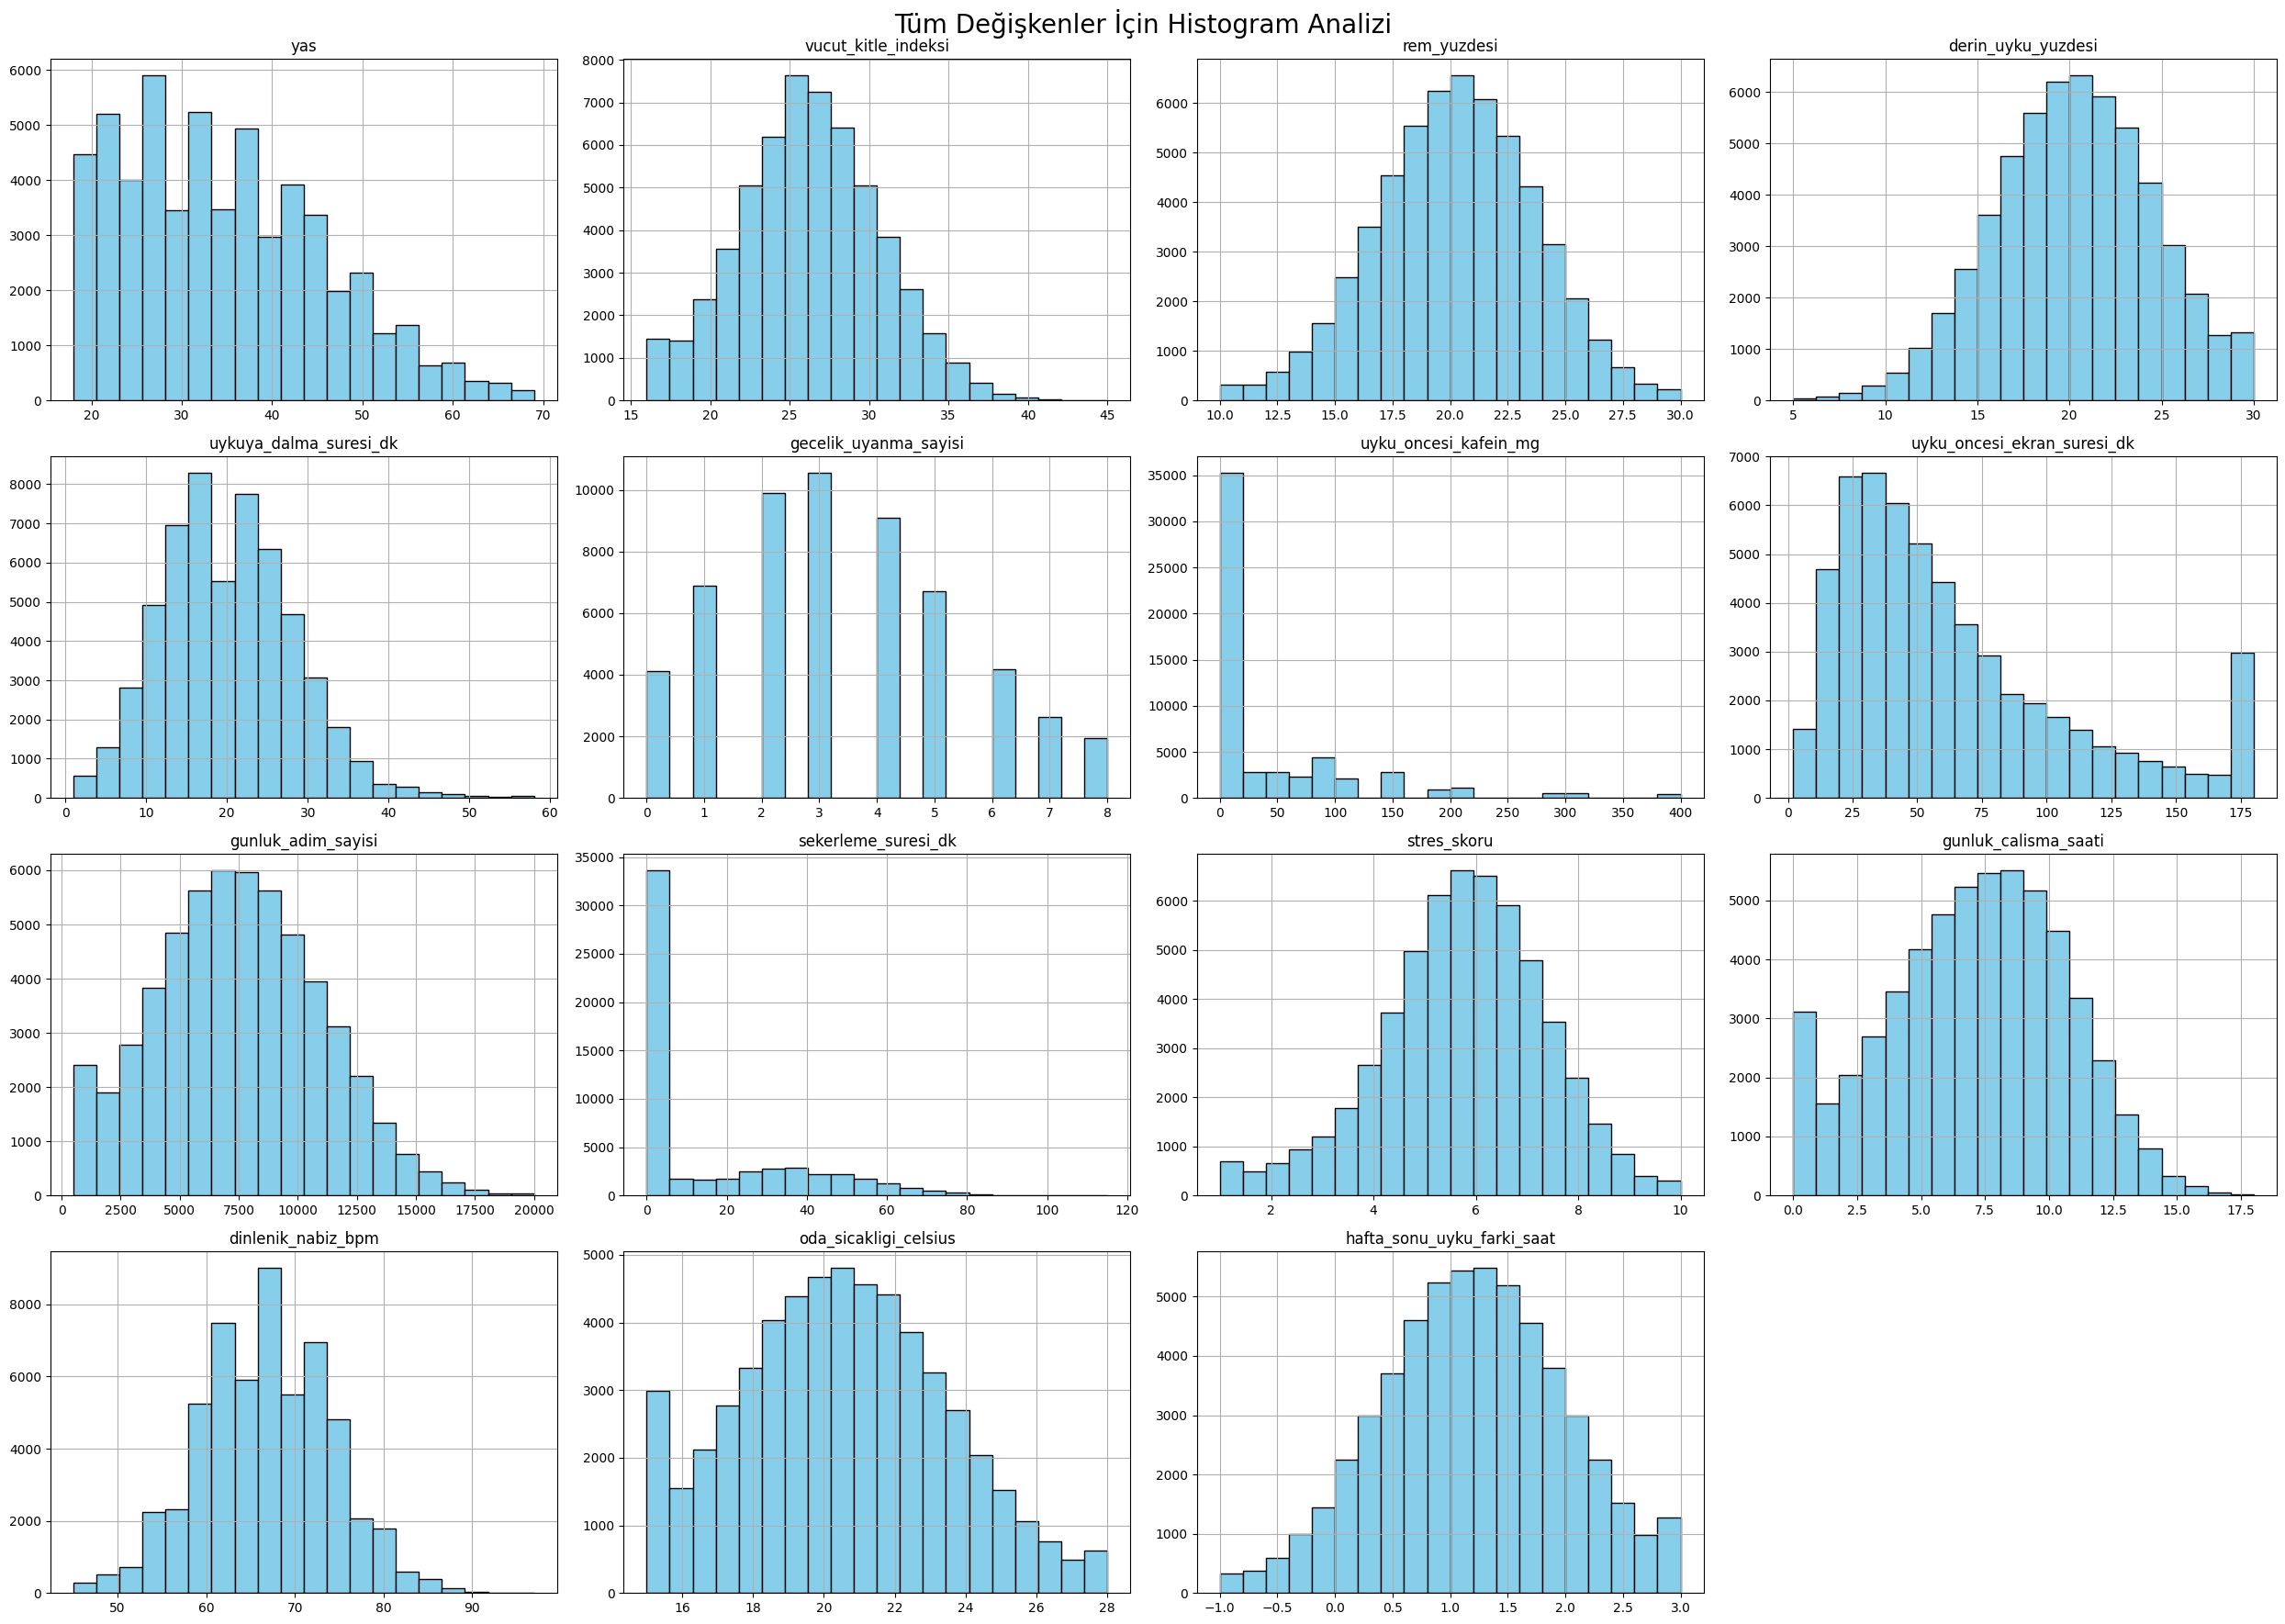

In [16]:
import matplotlib.pyplot as plt

numeric_cols.hist(bins=20, figsize=(25, 18), color='skyblue', edgecolor='black')

plt.suptitle('Tüm Değişkenler İçin Histogram Analizi', fontsize=20)
plt.tight_layout() # Grafikler arası boşlukları ayarlar
plt.subplots_adjust(top=0.95) # Başlığa yer açar
plt.show() 

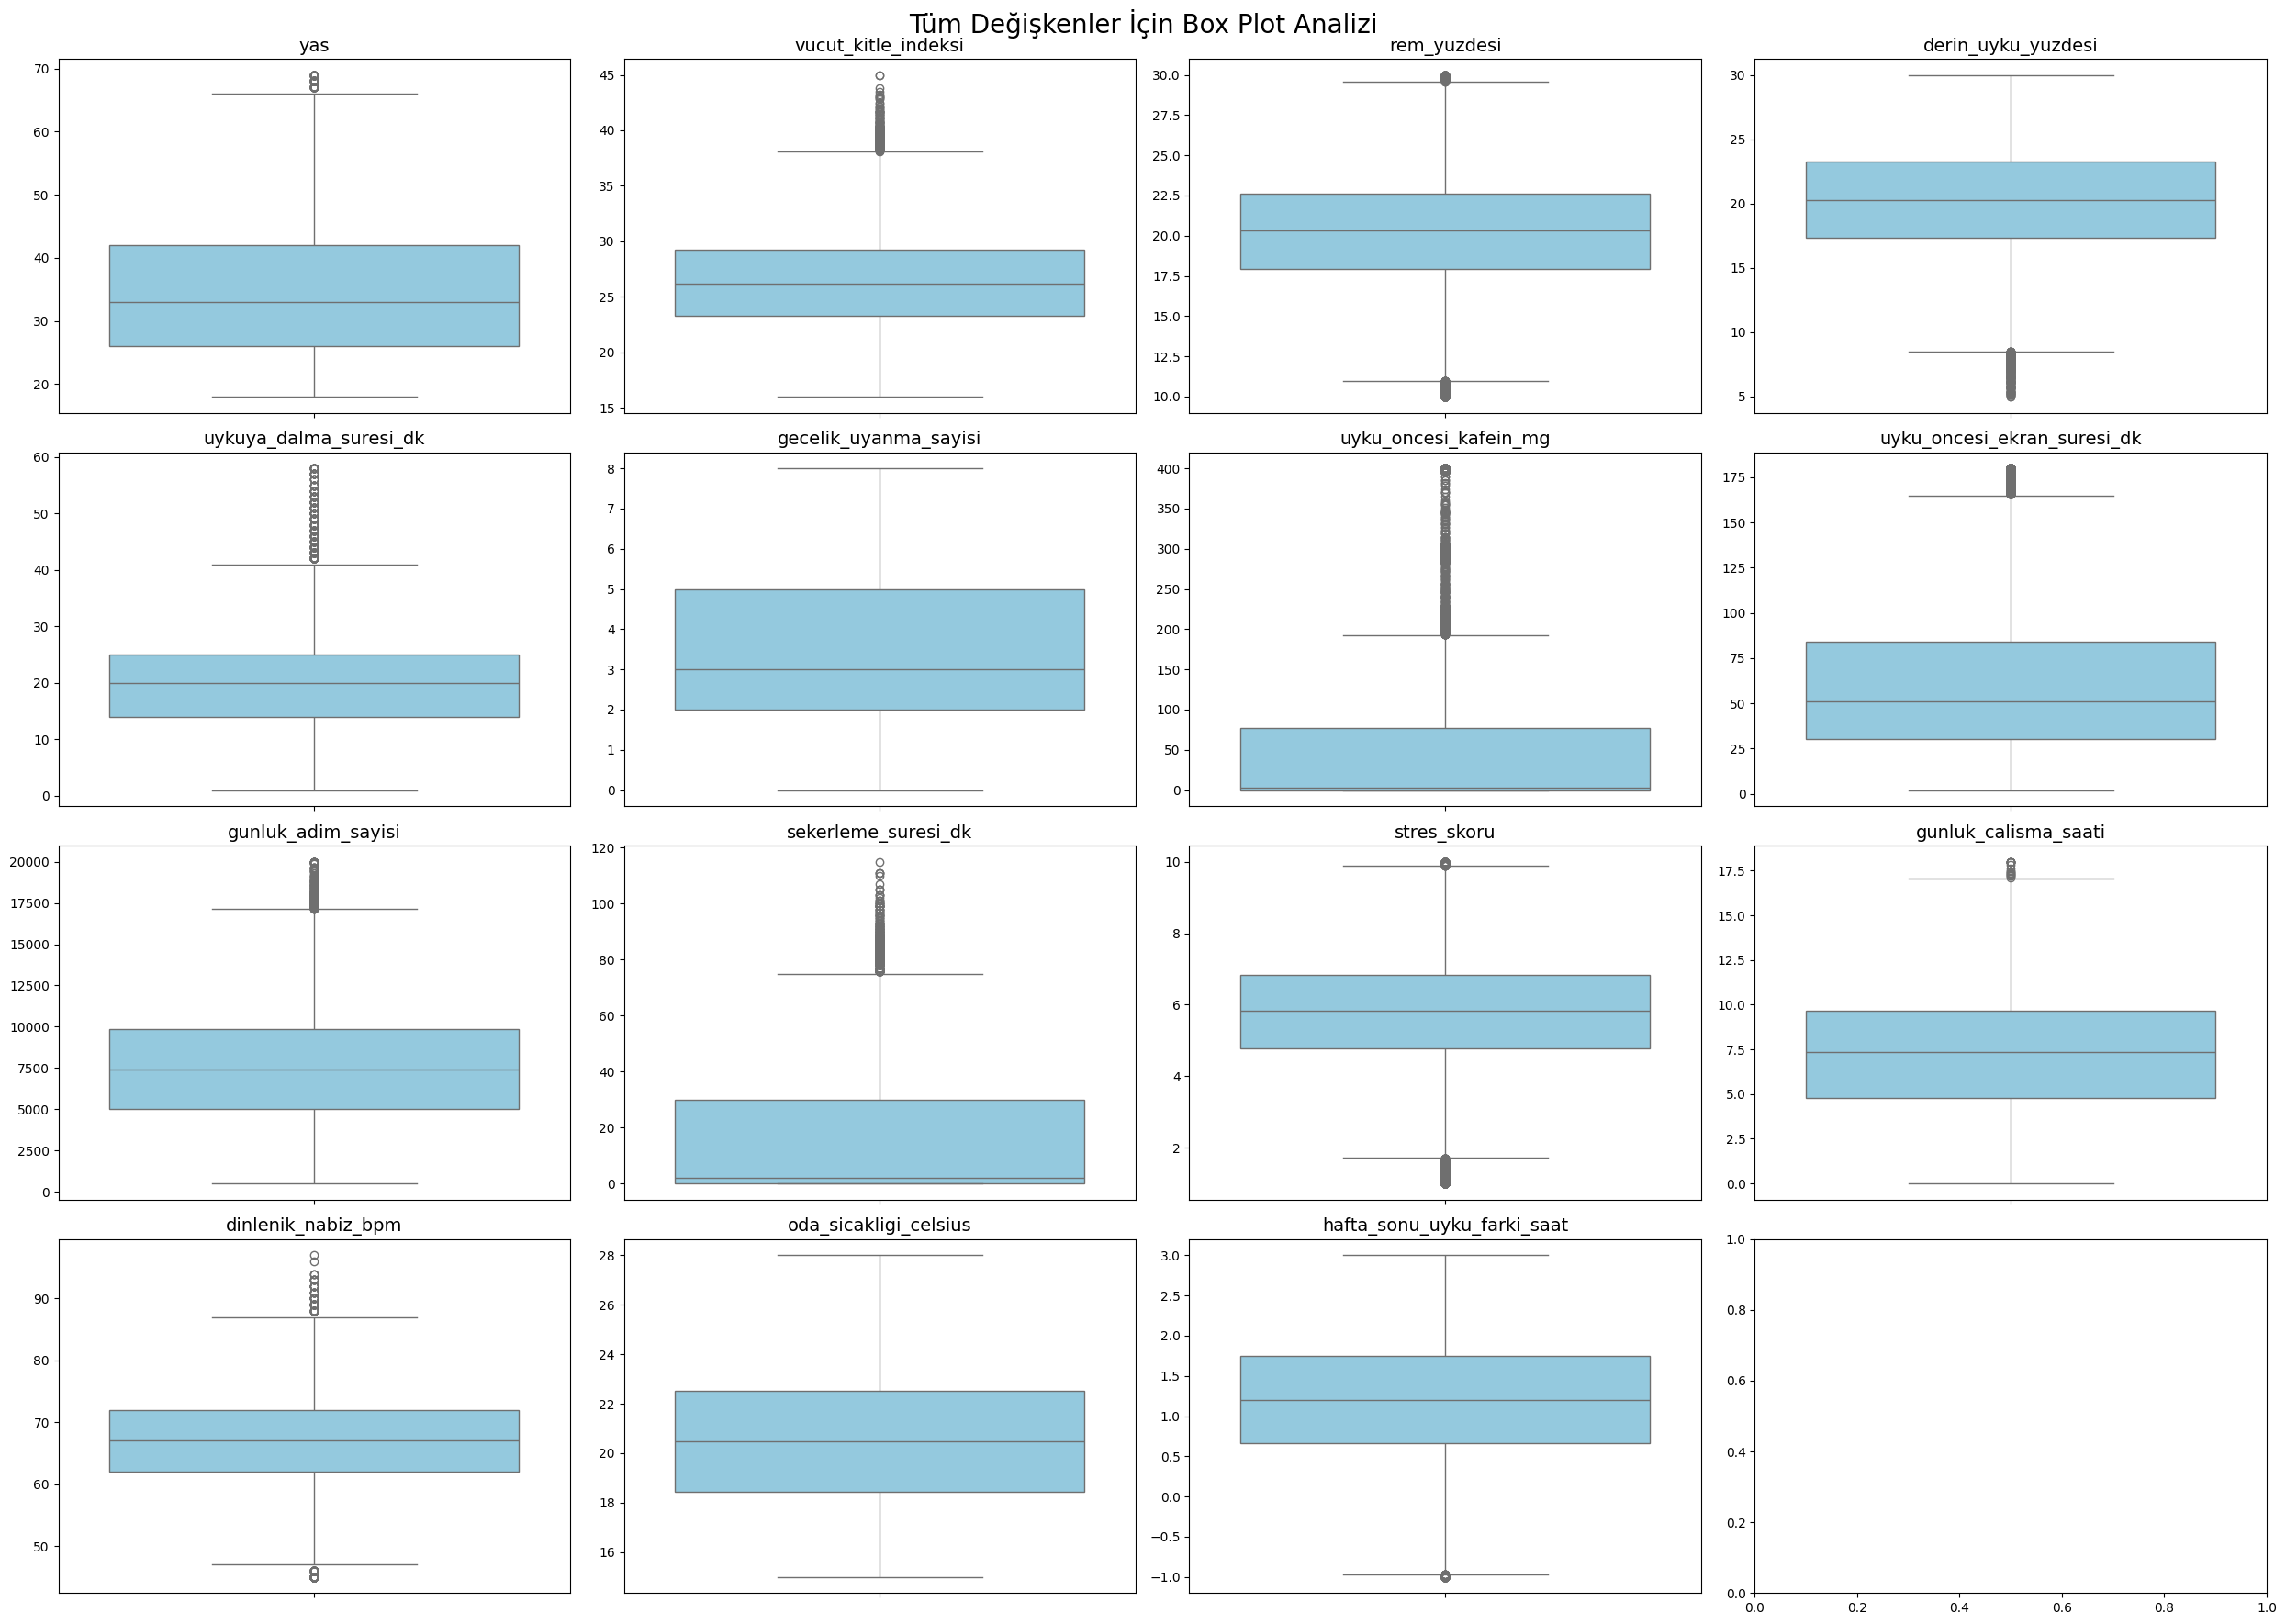

In [17]:
# box plot ile değişkenlerde aykırı değer tespiti

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 4, figsize=(25, 18))
fig.suptitle("Tüm Değişkenler İçin Box Plot Analizi", fontsize=20)

axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    if i < len(numeric_cols.columns): 

        sns.boxplot(y=numeric_cols[col], ax=axes[i], color="skyblue")
        axes[i].set_title(col, fontsize=14)
        axes[i].set_ylabel("") # grafik kalabalık olmasın diye y leri sildim.

for j in range(i + 1, len(numeric_cols.columns)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.show()

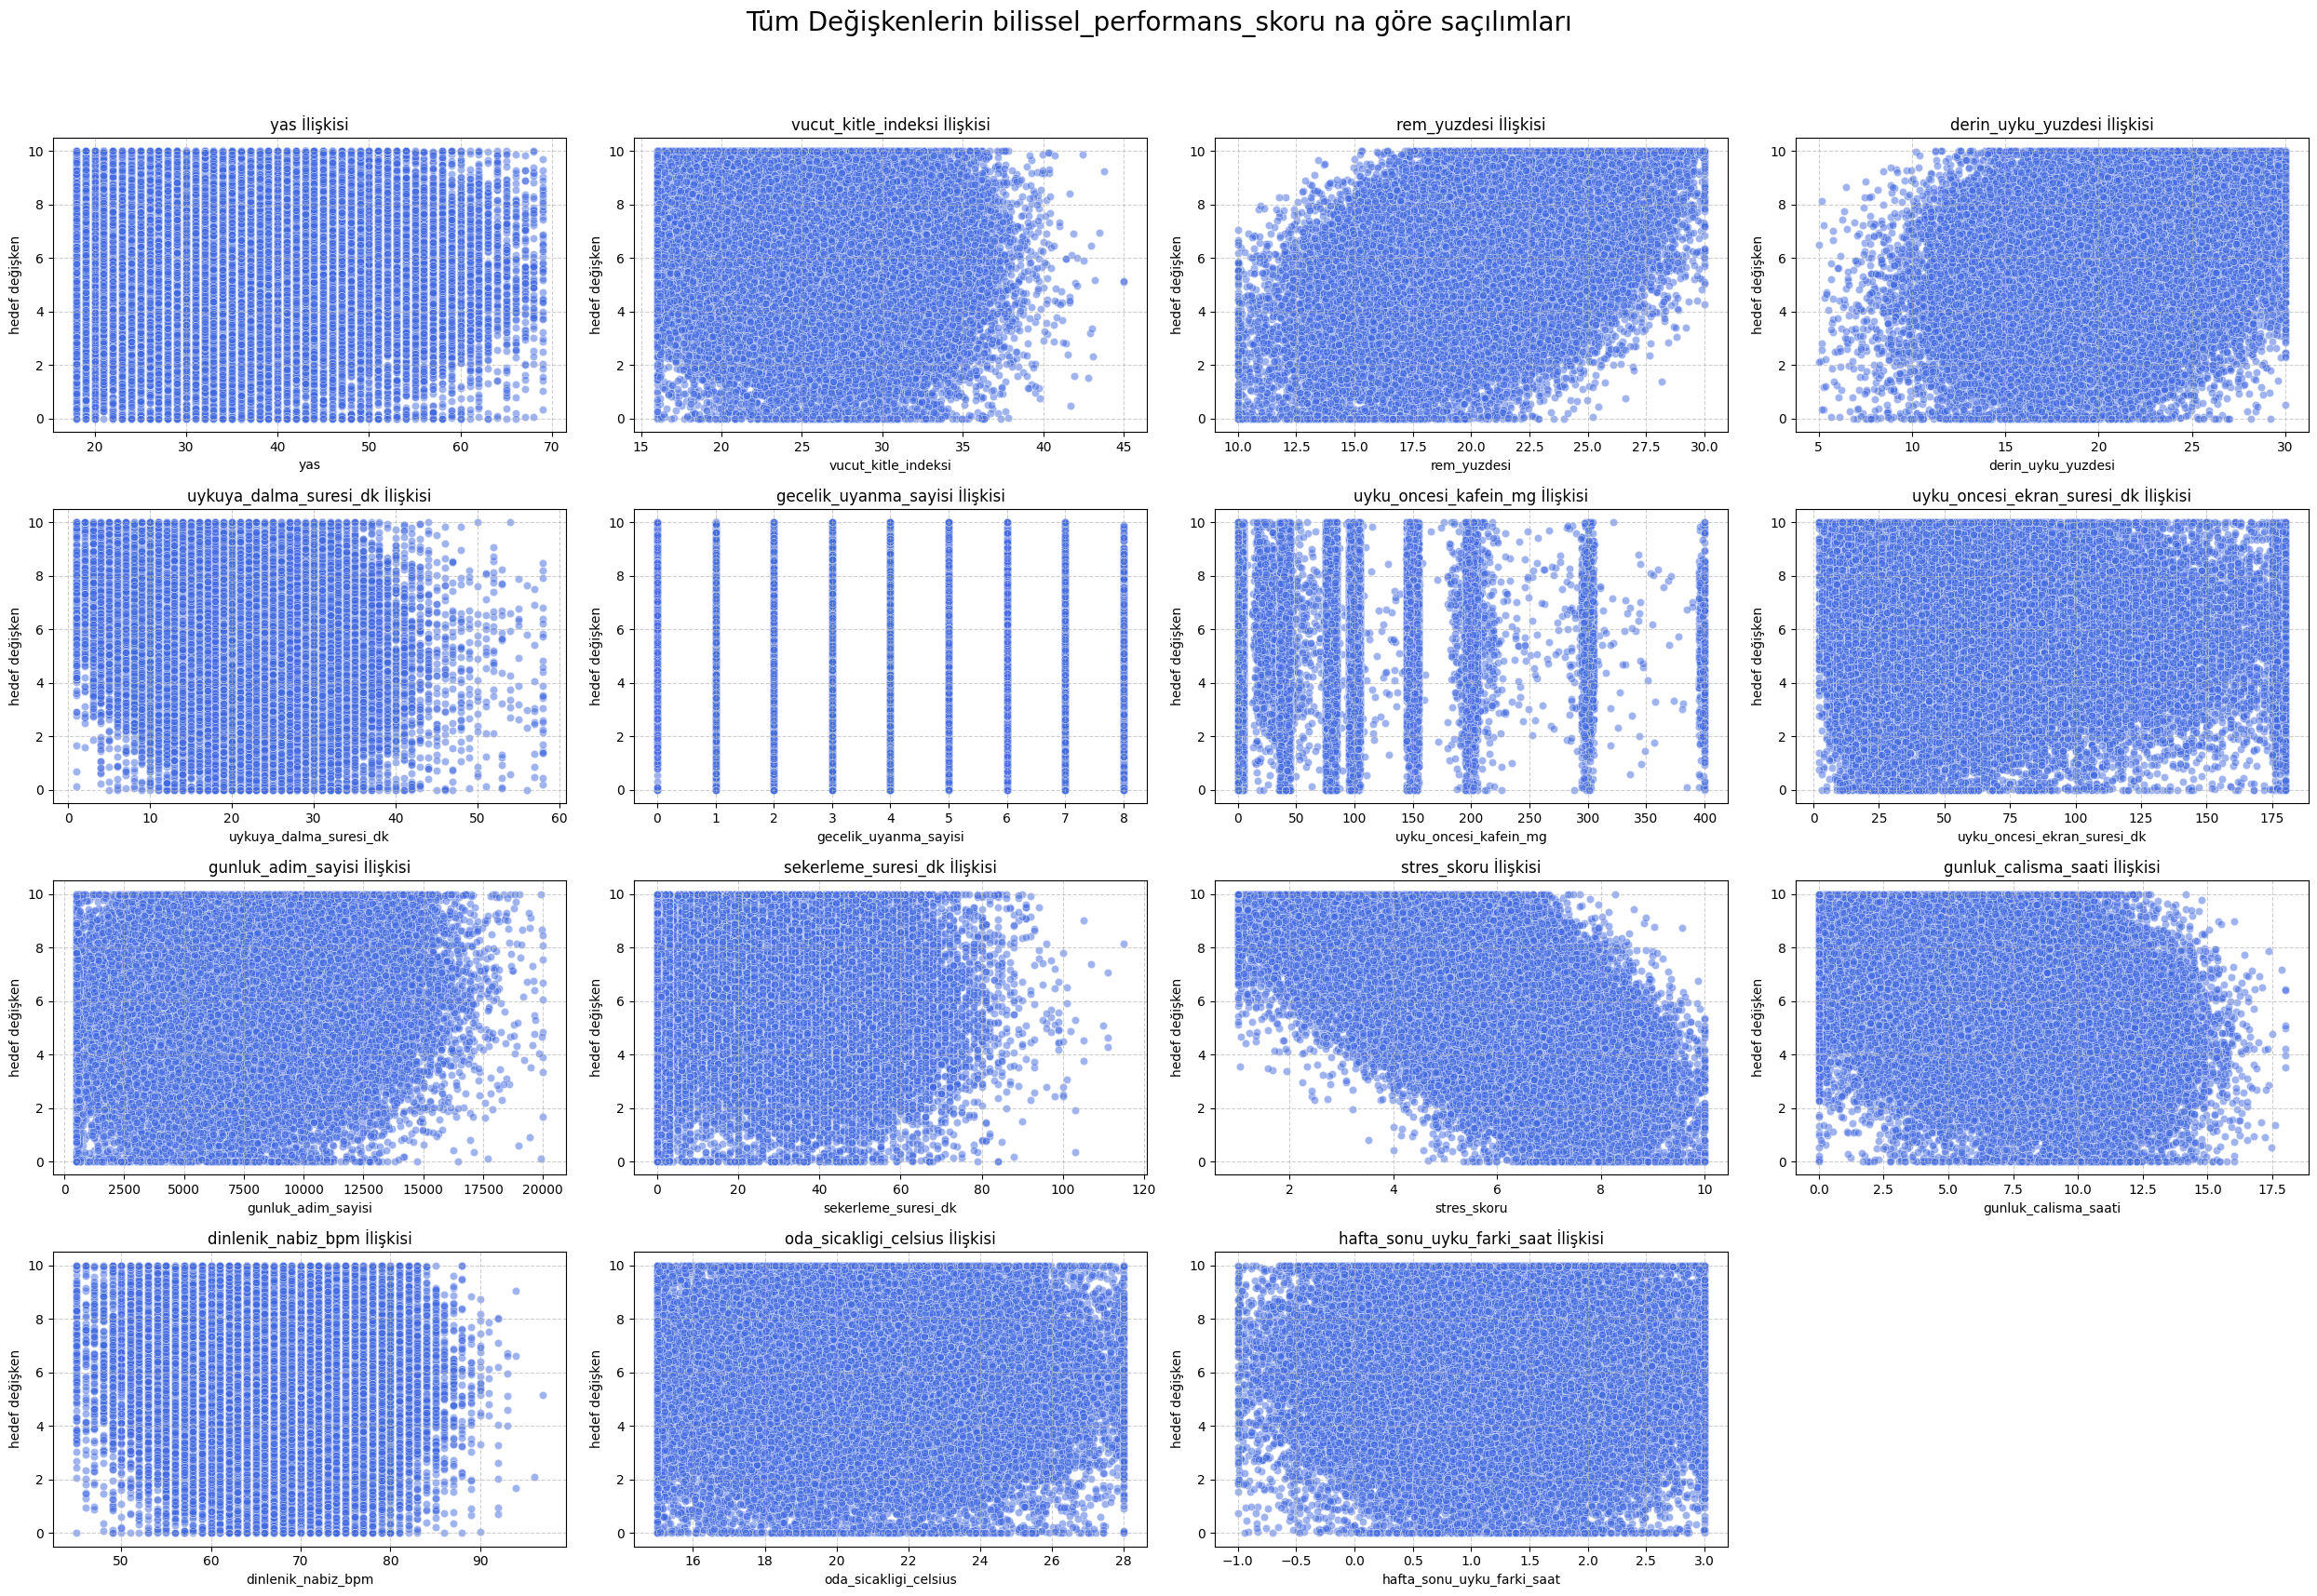

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hedef değişkenimiz
target = train_df["bilissel_performans_skoru"]
numeric_cols

fig, axes = plt.subplots(4, 4, figsize=(25, 18))
fig.suptitle("Tüm Değişkenlerin bilissel_performans_skoru na göre saçılımları", fontsize=20)

axes = axes.flatten()
for i, col in enumerate(numeric_cols.columns): # İlk 16 değişken için
    sns.scatterplot(data=numeric_cols, x=col, y=target, ax=axes[i], alpha=0.5, color='royalblue')
    
    axes[i].set_title(f"{col} İlişkisi", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("hedef değişken", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, 16):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Bağımsız değişkenlerin Bağımlı değişkene göre saçılımlarına baktığımda oldukça dağınık olduğu görülüyor. Bu sebeple lineer ya da non-linear regresyon modellemelerinden ziyade non-parametric modellerin daha uygun olabileceğini düşünüyorum.

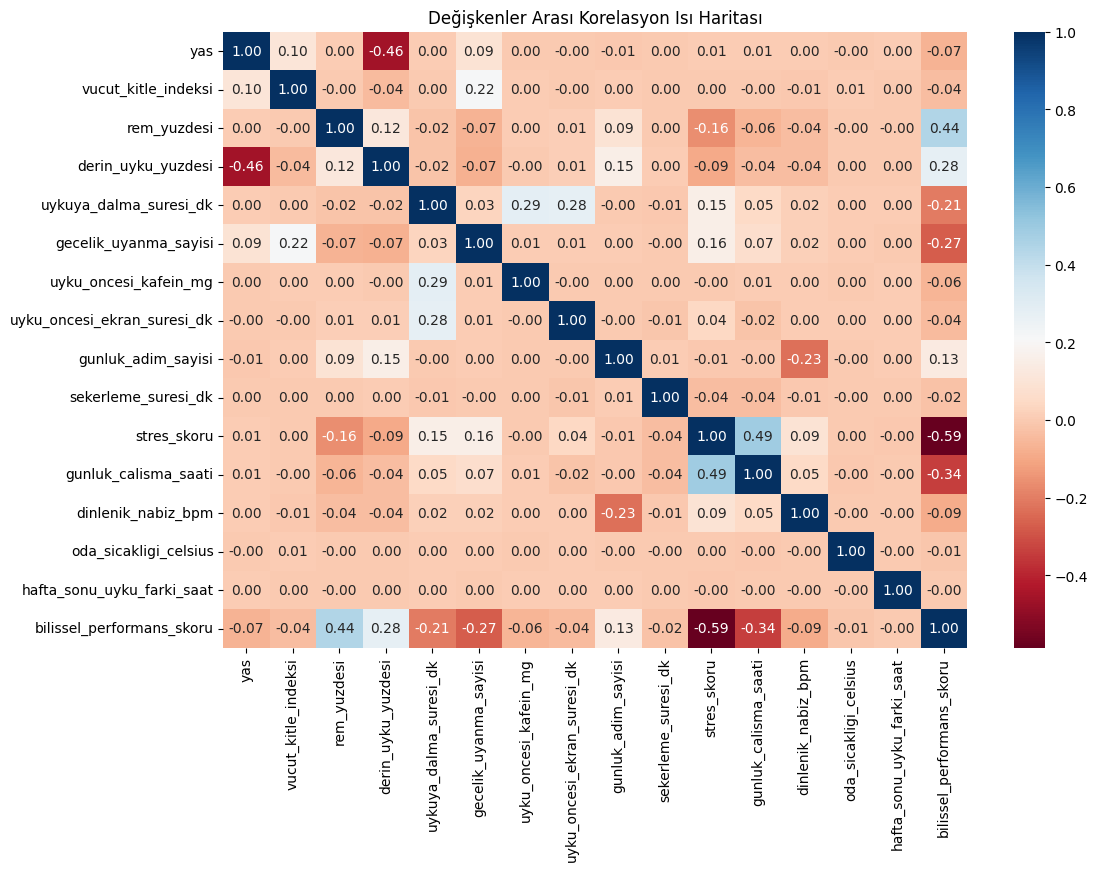

In [19]:
# Çoklu doğrusal model öncesinde değişkenler arasındaki ilişkilerini bakılır ki Bağımsız değişkenler arasında ilişki olmasın. VIF, Çoklu doğrusallık problemi, otokorelasyon problemi bunlara bak.

numeric_cols["bilissel_performans_skoru"]=train_df["bilissel_performans_skoru"]

import seaborn as sns
import matplotlib.pyplot as plt

corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="RdBu", fmt=".2f")
plt.title("Değişkenler Arası Korelasyon Isı Haritası")
plt.show() 

In [20]:
numeric_cols = numeric_cols.drop("hafta_sonu_uyku_farki_saat", axis=1) # Bağımlı değişken ile arasındaki korelasyon değeri 0 olduğu için çıkarttım.

### `Dummy değişkenler oluşturmak`

In [21]:
# X veri seti için dummy değişkenli güncel veriseti

encoder = OneHotEncoder(drop='first', sparse_output=False)
str_cols = X.select_dtypes(include=["object","category","str"]).columns
array = encoder.fit_transform(X[str_cols]) 
encoded_cols = encoder.get_feature_names_out(str_cols)
encoded_data = pd.DataFrame(array, columns=encoded_cols, index=X.index) 

new_X = X.drop(columns=str_cols) 
current_X = pd.concat([new_X, encoded_data], axis=1)

nan_encoded_data = current_X.drop(encoded_data, axis=1)

In [22]:
# X_test veri seti için dummy değişkenli güncel veriseti

encoder = OneHotEncoder(drop='first', sparse_output=False)
str_cols = X_test.select_dtypes(include=["object","category","str"]).columns
array = encoder.fit_transform(X_test[str_cols]) 
encoded_cols_test = encoder.get_feature_names_out(str_cols)
encoded_data_test = pd.DataFrame(array, columns=encoded_cols, index=X_test.index) 

new_X_test = X_test.drop(columns=str_cols) 
current_X_test = pd.concat([new_X_test, encoded_data_test], axis=1)

nan_encoded_data_test = current_X_test.drop(encoded_data, axis=1)

### **<span style="color:ORANGE">Aykırı değerlere uygun ölçeklendirme işlemi </span>**

Robust(Demokrasi aracı), aykırı değerlere uygun şekilde ölçeklendirilir. Scaling yaptığım zaman medyan, standart sapma ve varyans aykırı değerlerden etkilenmeden ölçeklendirilecek. Robust uygulanan bütün değişkenler ölçeklendirilir. 
StandartScaler da olduğu gibi aykırı değerleri çekiştirmeye çalışmaz. 

In [26]:
# Ölçeklendirilmiş numeric değişkenlerin bulunduğu train veri seti.
import pandas as pd

robust_scaler = RobustScaler() 
cols_to_scale = nan_encoded_data.columns # Çarpık/Aykırı değişkenlerin
nan_encoded_data[cols_to_scale] = robust_scaler.fit_transform(nan_encoded_data[cols_to_scale])

current_X_scaled = pd.concat([nan_encoded_data, encoded_data], axis=1)

# Ölçeklendirilmiş numeric değişkenlerin bulunduğu test veri seti.

nan_encoded_data_test[cols_to_scale] = robust_scaler.fit_transform(nan_encoded_data_test[cols_to_scale])

current_X_scaled_test = pd.concat([nan_encoded_data_test, encoded_data_test], axis=1)

In [27]:
# ölçeklendirilmiş y değişkeni
from sklearn.preprocessing import RobustScaler
import pandas as pd

y_scaler = RobustScaler() 
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

In [28]:
display(encoded_data.head())
display(nan_encoded_data.head())
current_X_scaled.head()

,cinsiyet_Kadin,meslek_Emekli,meslek_Ev Hanimi,meslek_Lawyer,meslek_Lojistik Calisani,meslek_Muhendis,meslek_Ogrenci,meslek_Saglik Personeli,meslek_Satis ve Pazarlama Calisani,meslek_Serbest Calisan,...,ulke_Spain,ulke_Sweden,ulke_Yeni Zelanda,kronotip_Notr,kronotip_Sabah insani,ruh_sagligi_durumu_Anksiyete ve depresyon,ruh_sagligi_durumu_Depresyon,ruh_sagligi_durumu_Saglikli,mevsim_Sonbahar-Kis,gun_tipi_Hafta sonu
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat
0,0.0625,0.886793,-1.263545,-0.958817,0.636364,1.333333,-0.038961,0.851852,-0.050062,-0.066667,2.004805,0.545769,1.1,-0.375167,-1.178199
1,-0.0625,0.804346,0.316295,1.176416,0.000000,0.333333,0.012987,2.388889,-0.490070,-0.033333,0.393659,-0.211771,0.9,0.181605,-0.240102
2,0.3750,-0.789483,-0.456985,0.889409,1.181818,1.333333,1.883117,-0.518519,0.701283,2.266667,0.133246,-0.718986,-0.1,-0.493257,0.034103
3,0.4375,-0.489721,0.244473,-0.747287,0.090909,-0.333333,-0.038961,2.388889,-0.452627,3.766667,-1.296485,-0.561857,-0.7,0.338206,-0.438438
4,0.1875,0.577258,1.111772,-0.668237,0.090909,1.666667,1.259740,1.740741,-0.700041,-0.066667,0.673300,-0.848158,0.7,-0.311018,-1.315906


,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,...,ulke_Spain,ulke_Sweden,ulke_Yeni Zelanda,kronotip_Notr,kronotip_Sabah insani,ruh_sagligi_durumu_Anksiyete ve depresyon,ruh_sagligi_durumu_Depresyon,ruh_sagligi_durumu_Saglikli,mevsim_Sonbahar-Kis,gun_tipi_Hafta sonu
0,0.0625,0.886793,-1.263545,-0.958817,0.636364,1.333333,-0.038961,0.851852,-0.050062,-0.066667,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,-0.0625,0.804346,0.316295,1.176416,0.000000,0.333333,0.012987,2.388889,-0.490070,-0.033333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.3750,-0.789483,-0.456985,0.889409,1.181818,1.333333,1.883117,-0.518519,0.701283,2.266667,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.4375,-0.489721,0.244473,-0.747287,0.090909,-0.333333,-0.038961,2.388889,-0.452627,3.766667,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,0.1875,0.577258,1.111772,-0.668237,0.090909,1.666667,1.259740,1.740741,-0.700041,-0.066667,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


### **<span style="color:ORANGE">Data Cleaning</span>**

In [29]:
current_X = current_X.drop("hafta_sonu_uyku_farki_saat", axis=1) # hedef değişken ile 0 korelasyon olduğu için çıkarttım.
current_X_scaled = current_X_scaled.drop("hafta_sonu_uyku_farki_saat", axis=1) # hedef değişken ile 0 korelasyon olduğu için çıkarttım.
current_X_scaled_test = current_X_scaled_test.drop("hafta_sonu_uyku_farki_saat", axis=1)
current_X_test = current_X_test.drop("hafta_sonu_uyku_farki_saat", axis=1) 

### **<span style="color:ORANGE">Güncel train verimiz için train ve valid split işlemi</span>**

In [30]:
from sklearn.model_selection import train_test_split

# 2. Train-Test Split işlemini gerçekleştiriyoruz
X_train, X_valid, y_train, y_valid = train_test_split(
    current_X_scaled, 
    y_scaled, 
    test_size=0.2,       # Verinin %20'si test, %80'i eğitim için ayrılır
    random_state=42,     # Sonuçların tekrarlanabilir olması için sabitliyoruz
    shuffle=True         # Veriyi ayırmadan önce karıştırır (genelde True istenir)
)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (44800, 46)
Test seti boyutu: (24000, 22)


`X_train` `X_valid` `y_train` `y_valid`

`X_test:` Yukarıdaki veriler ile modelimizi eğiteceğiz. Bu veri ile tahmin değerleri üreteceğiz.

## **<span style="color:ORANGE">Tahmin modellemeleri </span>**

### **<span style="color:lightblue">LightGBM</span>** **<span style="color:blue">(Seçtiğimiz model)</span>**

In [31]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import BaggingRegressor


lgbm_model = LGBMRegressor(n_estimators=1000, learning_rate=0.02, subsample=0.7, colsample_bytree=0.8, reg_alpha=10)
lgbm_model.fit(X_train, y_train)



# Modelin eğitim aşamasındaki tahmin değerleri ve metrikleri
prediction = lgbm_model.predict(X_train) 

r2 = r2_score(y_train, prediction) 
mse = mean_squared_error(y_train, prediction) 
rmse = np.sqrt(mse)

# Modelin hiç görmediği valid setindeki performansları ve tahminleri
prediction_valid = lgbm_model.predict(X_valid)

r2_valid = r2_score(y_valid, prediction_valid) # veya Random.score(X_valid, y_valid)
mse_valid = mean_squared_error(y_valid, prediction_valid) 
rmse_valid = np.sqrt(mse_valid)


print(f"R2_train Skoru:   {r2:.4f}")
print(f"R2_valid Skoru:   {r2_valid:.4f}")

print(f"MSE_train Değeri: {mse:.4f}")
print(f"MSE_valid Değeri: {mse_valid:.4f}")


print(f"RMSE_train Değeri: {rmse:.4f}")
print(f"RMSE_valid Değeri: {rmse_valid:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2499
[LightGBM] [Info] Number of data points in the train set: 44800, number of used features: 46
[LightGBM] [Info] Start training from score -0.037301
R2_train Skoru:   0.7350
R2_valid Skoru:   0.7015
MSE_train Değeri: 0.1304
MSE_valid Değeri: 0.1484
RMSE_train Değeri: 0.3612
RMSE_valid Değeri: 0.3853


### **<span style="color:lightblue">Out_of_Bagging Model</span>**

In [ ]:
# Encoding yapıldıktan sonra tahmin modeli

bag_clf_oob = BaggingRegressor(
    DecisionTreeRegressor(), 
    n_estimators=500,
    max_samples=0.9, 
    bootstrap=True, 
    n_jobs=-1, 
    oob_score = True) 

bag_clf_oob.fit(X_train, y_train) 

# Modelin eğitim aşamasındaki tahmin değerleri ve metrikleri
y_oob_pred = bag_clf_oob.oob_prediction_
r2_train = bag_clf_oob.oob_score_
mse_train = mean_squared_error(y_train, y_oob_pred)
rmse_train = np.sqrt(mse_train)

# Modelin hiç görmediği valid setindeki performansları ve tahminleri
y_valid_pred = bag_clf_oob.predict(X_valid)
r2_valid = bag_clf_oob.score(X_valid, y_valid) 

mse_valid = mean_squared_error(y_valid, y_valid_pred)
rmse_valid = np.sqrt(mse_valid)


print(f"OOB R2 Skoru:   {r2_train:.4f}")
print(f"OOB R2_valid Skoru:   {r2_valid:.4f}")

print(f"OOB MSE Değeri: {mse_train:.4f}")
print(f"OOB MSE_valid Değeri: {mse_valid:.4f}")


print(f"OOB RMSE Değeri: {rmse_train:.4f}")
print(f"OOB RMSE_valid Değeri: {rmse_valid:.4f}")

### **<span style="color:lightblue">XGBoost</span>**

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    subsample=0.6,
    reg_alpha=5,
    colsample_bytree=0.3,
    importance_type='gain')

xgb = xgb_model.fit(X_train, y_train)

# Modelin eğitim aşamasındaki tahmin değerleri ve metrikleri
prediction = xgb.predict(X_train) 

r2 = r2_score(y_train, prediction) # veya Random.score(X_valid, y_valid)
mse = mean_squared_error(y_train, prediction) 
rmse = np.sqrt(mse)

# Modelin hiç görmediği valid setindeki performansları ve tahminleri
prediction_valid = xgb.predict(X_valid)

r2_valid = r2_score(y_valid, prediction_valid) # veya Random.score(X_valid, y_valid)
mse_valid = mean_squared_error(y_valid, prediction_valid) 
rmse_valid = np.sqrt(mse_valid)



print(f"OOB R2 Skoru:   {r2:.4f}")
print(f"OOB R2_valid Skoru:   {r2_valid:.4f}")

print(f"OOB MSE Değeri: {mse:.4f}")
print(f"OOB MSE_valid Değeri: {mse_valid:.4f}")


print(f"OOB RMSE Değeri: {rmse:.4f}")
print(f"OOB RMSE_valid Değeri: {rmse_valid:.4f}")

### **<span style="color:orange">Submittion</span>**

In [32]:
prediction_test = lgbm_model.predict(current_X_scaled_test) 
prediction_test 

array([ 0.01453723,  0.21513499, -1.03795389, ..., -0.19510572,
       -0.2686992 , -0.86802414], shape=(24000,))

In [33]:
prediction_test_original = y_scaler.inverse_transform(prediction_test.reshape(-1, 1)).flatten() # Ölçekli hali ile tahmin ettiğimiz bilissel_performans_skoru değerlerini ölçeklsiz haline getirip en baştaki test_df verisine ekliyoruz.
prediction_test_original 

array([6.07844147, 6.71585062, 2.73409962, ..., 5.41229076, 5.17844388,
       3.27405969], shape=(24000,))

In [34]:
test_df["bilissel_performans_skoru"] = prediction_test_original

In [35]:
submission = pd.DataFrame({
    "id": test_df["id"], 
    "bilissel_performans_skoru": test_df["bilissel_performans_skoru"]}) 

submission.to_csv("submission_new.csv", index=False) 

In [36]:
submission

,id,bilissel_performans_skoru
0,1,6.078441
1,2,6.715851
2,3,2.734100
3,4,7.107170
4,5,3.392379
...,...,...
23995,23996,3.256337
23996,23997,3.676463
23997,23998,5.412291
23998,23999,5.178444
